**Double click here and enter the student numbers for all group members. Don't enter any names.**

Now **[click on this link and read the MATH0011 project instructions.](https://www.ucl.ac.uk/~ucahmto/project_instructions.html)**

# The Music of the Primes

In this project you will learn about some number theoretical functions related to the distribution of the prime numbers, use the non-trivial zeros of the Riemann zeta function to make plots related to the error term in the prime number theorem, and finally create an audio file containing the true "music of the primes."  You will use `numpy` to generate arrays for plotting, `matplotlib` to plot functions, `sympy` for its prime-generation functions and `scipy` to write audio data.

Put **all** of your import commands in the box below.  You only need to import a module once per notebook.  Don't put imports anywhere else in your notebook.

In [4]:
import numpy as np
import sympy as sp
import scipy
import matplotlib.pyplot as plt
import IPython
import math

## Part 1: the first Chebyshev function

The *first Chebyshev function* is defined by
$$\theta(x) = \sum_{p \leqslant x} \log p.$$
Here $\log$ means the natural logarithm, to base $e = 2.718281828\cdots$.   The summation is over all prime numbers $p$ less than or equal to $x$, so that for example
$$\theta(18) = \log 2 + \log 3 + \log 5 + \log 7 + \log 11 + \log 13 + \log 17$$
because the prime numbers which are less than or equal to 18 are 2, 3, 5, 7, 11, 13, and 17.

You are going to write a Python function computing $\theta(x)$. Computing all of
the prime numbers between $2$ and $x$ every time you want to evaluate
$\theta(x)$ would be very inefficient, because you would be doing the same calcluation
lots of times. Instead, you will create an array of all of
the prime numbers in the range we are interested in once and then use that to
help compute values of $\theta$.

**Learn how to use `sympy`'s `primerange` function, and use it to generate a `numpy` array of all of the prime numbers $p$ with $2 \leqslant p \leqslant 1000$. Then make a numpy array of the natural logarithms of all the prime numbers $p$ in the same range.**

In [6]:
p = list(sp.primerange(2,1000))
primes = np.array(p)
logprime = np.array([math.log(x) for x in p])
print(primes)
print(logprime)

[  2   3   5   7  11  13  17  19  23  29  31  37  41  43  47  53  59  61
  67  71  73  79  83  89  97 101 103 107 109 113 127 131 137 139 149 151
 157 163 167 173 179 181 191 193 197 199 211 223 227 229 233 239 241 251
 257 263 269 271 277 281 283 293 307 311 313 317 331 337 347 349 353 359
 367 373 379 383 389 397 401 409 419 421 431 433 439 443 449 457 461 463
 467 479 487 491 499 503 509 521 523 541 547 557 563 569 571 577 587 593
 599 601 607 613 617 619 631 641 643 647 653 659 661 673 677 683 691 701
 709 719 727 733 739 743 751 757 761 769 773 787 797 809 811 821 823 827
 829 839 853 857 859 863 877 881 883 887 907 911 919 929 937 941 947 953
 967 971 977 983 991 997]
[0.69314718 1.09861229 1.60943791 1.94591015 2.39789527 2.56494936
 2.83321334 2.94443898 3.13549422 3.36729583 3.4339872  3.61091791
 3.71357207 3.76120012 3.8501476  3.97029191 4.07753744 4.11087386
 4.20469262 4.26267988 4.29045944 4.36944785 4.41884061 4.48863637
 4.57471098 4.61512052 4.63472899 4.67282883 4.69

Now **write a Python function `cheb1(x)` which computes $\theta(x)$ as defined above.**  

Do not call `primerange` or any other `sympy` function related to primes inside your function: just use the array you computed in the code cell above.

In [8]:
def cheb1(x):
    return np.sum(logprime[primes <= x])

cheb1(1000)

np.float64(956.2452651200588)

Check that your code works correctly by comparing its output to some entries in the table of values at the back of [*Approximate Formulas for Some Functions of Prime Numbers*](https://projecteuclid.org/journals/illinois-journal-of-mathematics/volume-6/issue-1/Approximate-formulas-for-some-functions-of-prime-numbers/10.1215/ijm/1255631807.full) by Rosser and Schoenfeld.  Don't trust the values the Google search AI summary gives - for me, at least, some of them were wrong.

You are going to plot a graph of $y = \theta(x)$.  To do this, you need an array or list of values of $\theta(x)$. Now that you've written `cheb1` there are easy ways to compute this, like the list comprehension
```python
[cheb1(x) for x in range(2, 1001)]
```
However, this is extremely inefficient.  Calling `cheb1(2)` means working out
$\log 2$.  Calling `cheb1(3)` means working out $\log 2$ and $\log 3$ and adding
them up.  Calling `cheb1(4)` means working out $\log(2)$ and $\log(3)$ and
adding them up. Calling `cheb1(5)` means working out $\log(2)$, $\log(3)$, and
$\log(5)$, and adding them up.  You can see that there will be a huge amount of
wasted computation: `cheb1(3)` is equal to `cheb1(2)` plus $\log(2)$. `cheb1(4)`
is equal to `cheb1(3)`.  `cheb1(5)` is `cheb1(4)` plus `log(5)`.  Instead, work
out the relationship between $\theta(x)$ and $\theta(x+1)$ for a positive
integer $x$ (it depends on whether $x+1$ is prime, which you can test by using
`sp.isprime(x+1)`) and use that to **compute a
list or an array `cheb1_values` containing all the values of `cheb1(x)` for `x` between 2 and
1000** *without* calling your `cheb1` function.

In [14]:
cheb1value = [math.log(2)]
sum = math.log(2)
    
for x in range(2,1000):
    if sp.isprime(x+1):
        sum = sum + math.log(x+1)
        cheb1value.append(sum)
    else:
        cheb1value.append(sum)
   

cheb1_values = np.array(cheb1value)
cheb1_values

array([6.93147181e-01, 1.79175947e+00, 1.79175947e+00, 3.40119738e+00,
       3.40119738e+00, 5.34710753e+00, 5.34710753e+00, 5.34710753e+00,
       5.34710753e+00, 7.74500280e+00, 7.74500280e+00, 1.03099522e+01,
       1.03099522e+01, 1.03099522e+01, 1.03099522e+01, 1.31431655e+01,
       1.31431655e+01, 1.60876045e+01, 1.60876045e+01, 1.60876045e+01,
       1.60876045e+01, 1.92230987e+01, 1.92230987e+01, 1.92230987e+01,
       1.92230987e+01, 1.92230987e+01, 1.92230987e+01, 2.25903945e+01,
       2.25903945e+01, 2.60243817e+01, 2.60243817e+01, 2.60243817e+01,
       2.60243817e+01, 2.60243817e+01, 2.60243817e+01, 2.96352996e+01,
       2.96352996e+01, 2.96352996e+01, 2.96352996e+01, 3.33488717e+01,
       3.33488717e+01, 3.71100718e+01, 3.71100718e+01, 3.71100718e+01,
       3.71100718e+01, 4.09602194e+01, 4.09602194e+01, 4.09602194e+01,
       4.09602194e+01, 4.09602194e+01, 4.09602194e+01, 4.49305113e+01,
       4.49305113e+01, 4.49305113e+01, 4.49305113e+01, 4.49305113e+01,
      

Use your `cheb1` function to check that the entries in `cheb1_values` are correct. (You might get tiny errors due to rounding - that's OK.)



In [10]:
np.array([cheb1(x) for x in range(2, 1001)])

array([6.93147181e-01, 1.79175947e+00, 1.79175947e+00, 3.40119738e+00,
       3.40119738e+00, 5.34710753e+00, 5.34710753e+00, 5.34710753e+00,
       5.34710753e+00, 7.74500280e+00, 7.74500280e+00, 1.03099522e+01,
       1.03099522e+01, 1.03099522e+01, 1.03099522e+01, 1.31431655e+01,
       1.31431655e+01, 1.60876045e+01, 1.60876045e+01, 1.60876045e+01,
       1.60876045e+01, 1.92230987e+01, 1.92230987e+01, 1.92230987e+01,
       1.92230987e+01, 1.92230987e+01, 1.92230987e+01, 2.25903945e+01,
       2.25903945e+01, 2.60243817e+01, 2.60243817e+01, 2.60243817e+01,
       2.60243817e+01, 2.60243817e+01, 2.60243817e+01, 2.96352996e+01,
       2.96352996e+01, 2.96352996e+01, 2.96352996e+01, 3.33488717e+01,
       3.33488717e+01, 3.71100718e+01, 3.71100718e+01, 3.71100718e+01,
       3.71100718e+01, 4.09602194e+01, 4.09602194e+01, 4.09602194e+01,
       4.09602194e+01, 4.09602194e+01, 4.09602194e+01, 4.49305113e+01,
       4.49305113e+01, 4.49305113e+01, 4.49305113e+01, 4.49305113e+01,
      

Finally, **use `cheb1_values` to plot a graph of $\theta(x)$ for $2 \leqslant x \leqslant 1000$ and draw the graph $y=x$ on the same axes**.  The famous [prime number theorem](https://en.wikipedia.org/wiki/Prime_number_theorem), that the ratio between the number of primes less than or equal to $N$ and $N/\log N$ tends to 1 as $N \to \infty$, is equivalent to the fact that $\theta(x)/x \to 1$ as $x \to \infty$. Your graph should show that the latter result is plausible: while $\theta(x)$ will be a little less than $x$, the relative difference is small.

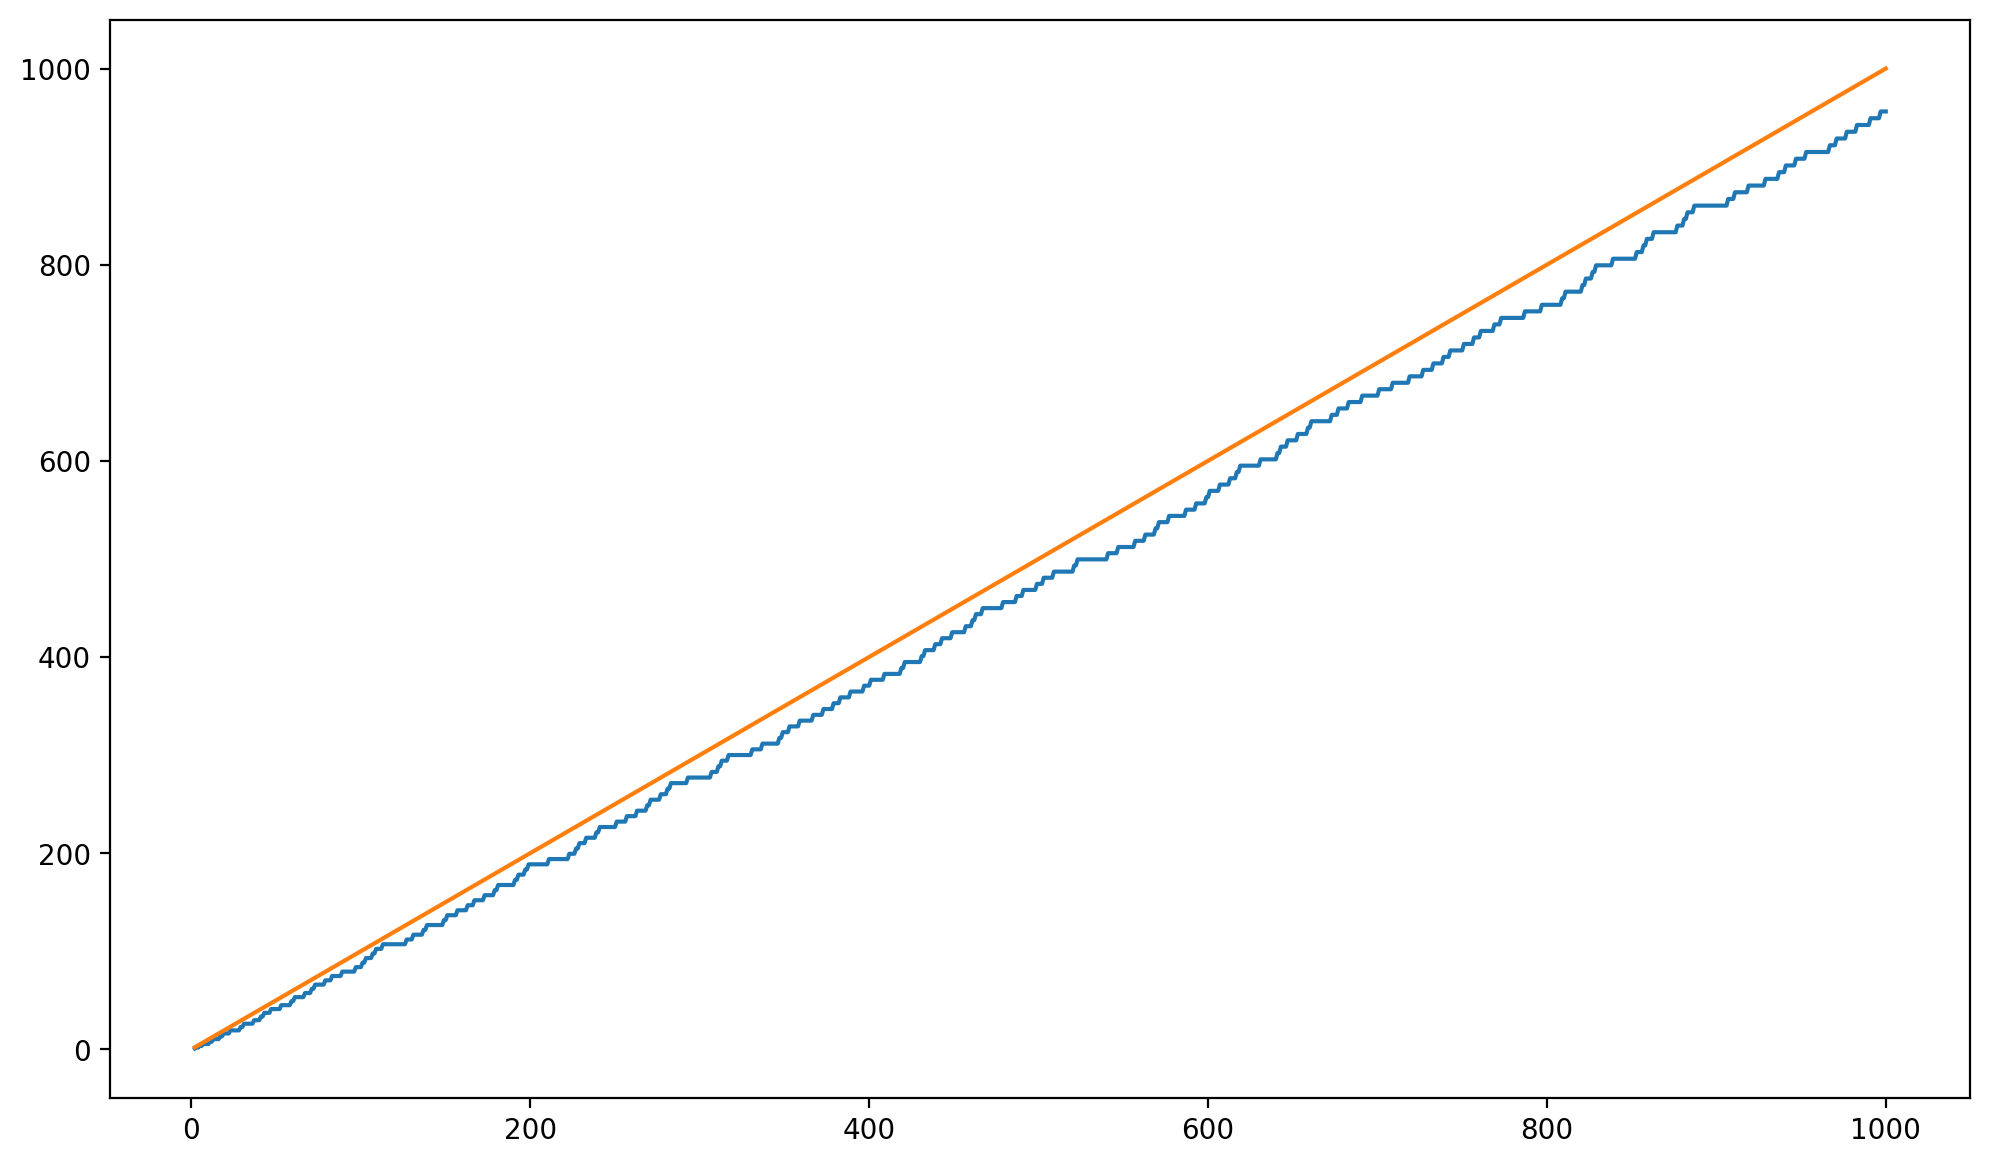

In [11]:
xs = [x for x in range(2,1001)]
ys = cheb1_values

plt.plot(xs,ys)
plt.plot(xs,xs)

## Part 2: the second Chebyshev function

The second Chebyshev function is defined to be $\psi(x) = \sum_{p \leqslant x} \lfloor \log_p(x) \rfloor \log p$.  Here $\lfloor a \rfloor$ is the result of rounding $a$ down to the largest integer less than or equal to $a$, so that for example $\lfloor 2.999\rfloor = \lfloor 2.1 \rfloor = \lfloor 2 \rfloor = 2$, $\log p$ is the natural logarithm of $p$ (to base $e = 2.71828\cdots$), and $\log_p(x)$ means the logarithm of $x$ taken to base $p$ (meaning that $p ^{\log_p(x)} = x$).  The sum means the same thing as before: you sum over all prime numbers $p$ wihch are less than $x$, so that for example

$$\psi(10) = \lfloor \log_2(10)\rfloor \log_2 + \lfloor \log_3(10)\rfloor \log _3 + \lfloor \log_5(10) \rfloor \log(5) + \lfloor \log_7(10)\rfloor \log(7)$$
because the prime numbers less than or equal to 10 are 2, 3, 5, and 7. 

**Write a function `cheb2(x)` which computes $\psi(x)$ as defined above.**

In [17]:
def cheb2(x):
    prime = primes[primes<=x]
    floors = np.floor(np.log(x)/np.log(prime))
    logs = np.log(prime)
    return np.dot(floors, logs)


Use the table of values of
$\psi(x)-\theta(x)$ given at the end of [*Approximate Formulas for Some Functions of Prime Numbers*](https://projecteuclid.org/journals/illinois-journal-of-mathematics/volume-6/issue-1/Approximate-formulas-for-some-functions-of-prime-numbers/10.1215/ijm/1255631807.full) by Rosser and Schoenfeld to check that your function is working correctly.

In [16]:
cheb1(8) - cheb2(8)

np.float64(-1.3862943611198908)

It was possible to generate an array of values of $\theta(x)$ efficiently because of the nice relationship between $\theta(x)$ and $\theta(x+1)$. There isn't such a nice relationship for $\psi$, so - any way you can - **plot the graph of $y=\psi(x)$ for $2 \leqslant x \leqslant 50$ and the graph of $y=x - \log(2\pi)$ on the same axis.** It's again true that $\psi(x)/x \to 1$ as $x \to \infty$.

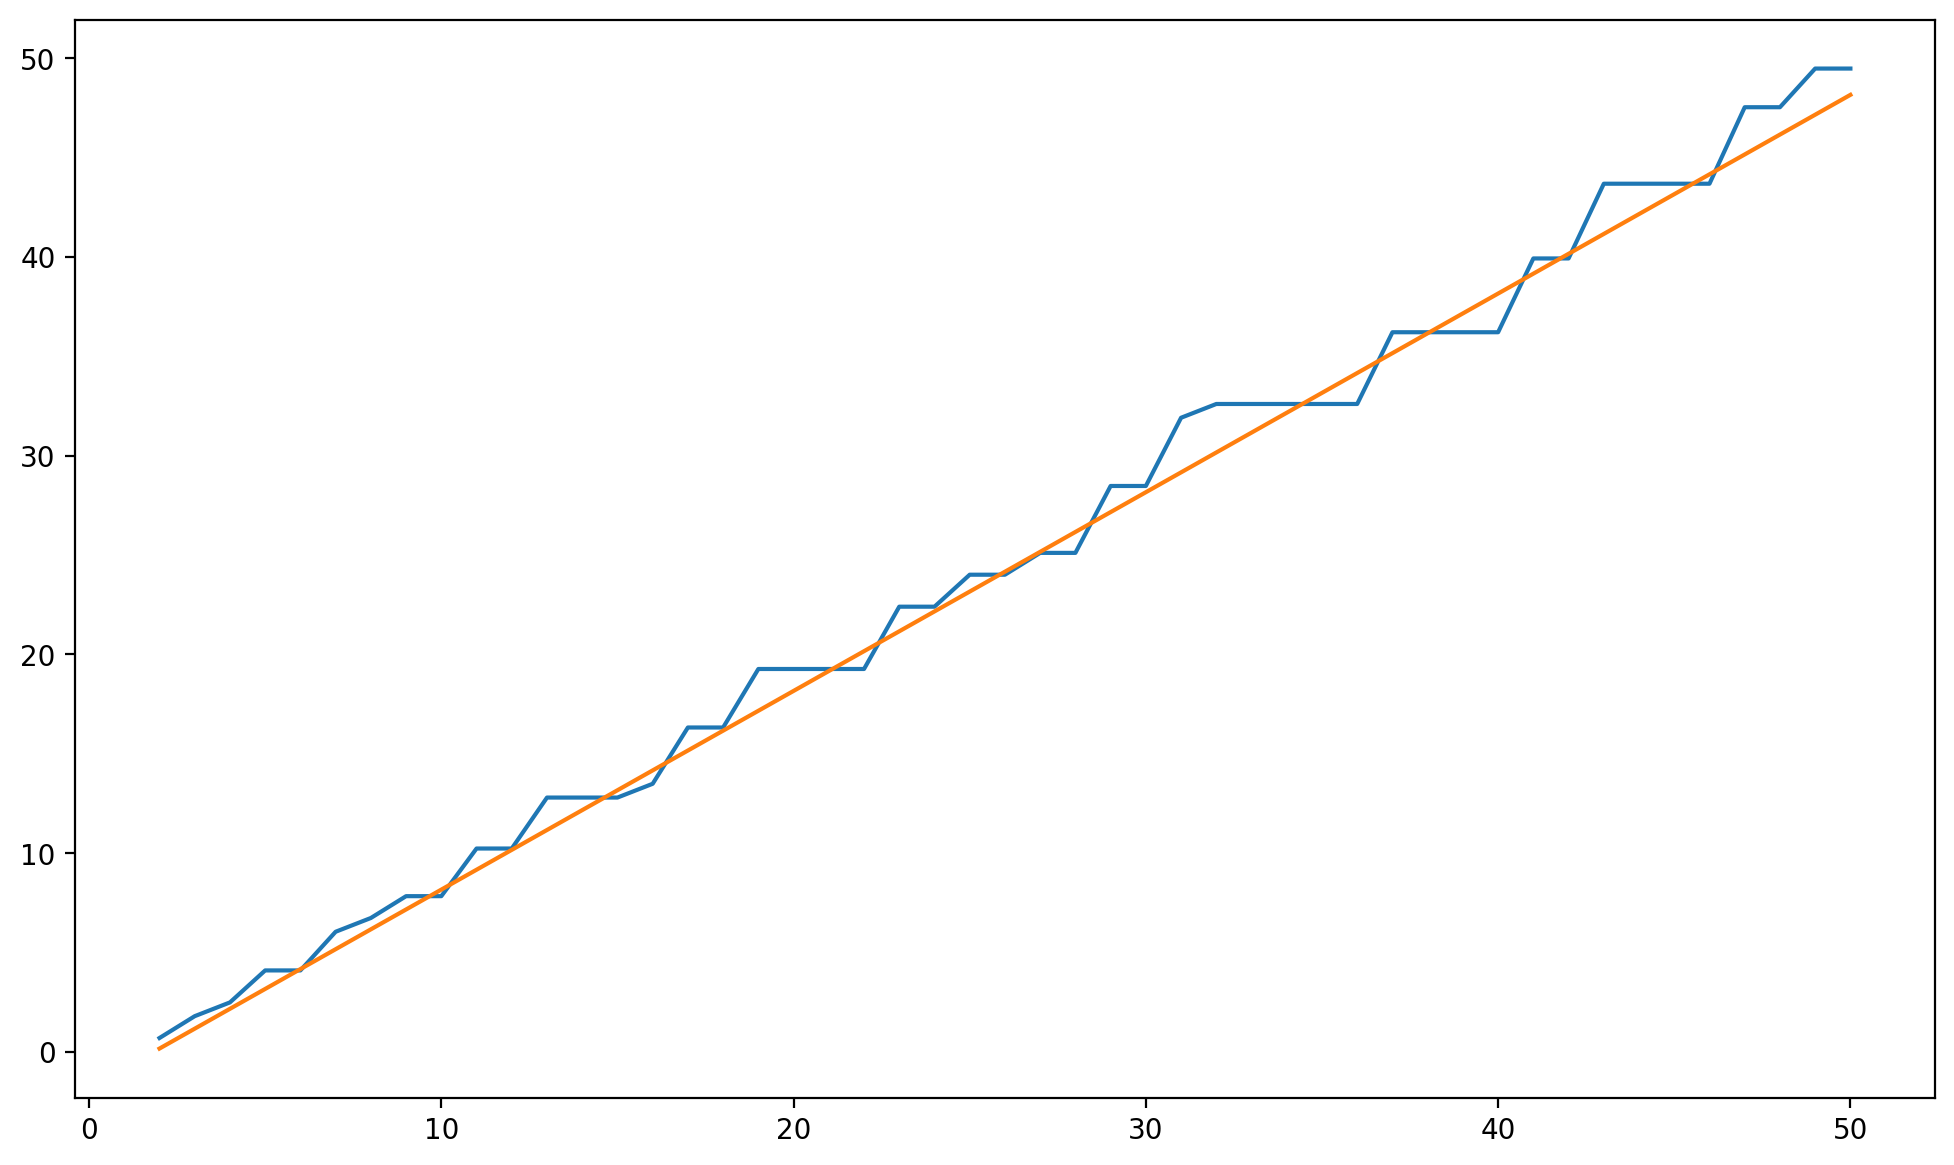

In [21]:
ys = [cheb2(x) for x in range(2,51)]
y = [(x-math.log(2*math.pi)) for x in range(2,51)]
xs = [x for x in range(2,51)]

plt.plot(xs, ys)
plt.plot(xs, y)

## Part 3: non-trivial zeros of the Riemann zeta function

The Riemann zeta function $\zeta(s)$ is defined for every complex number except $s=1$. It has "trivial" zeros at $s=-2, -4, -6, \ldots$, meaning that $\zeta(-2) = 0$, $\zeta(-4) = 0$, $\zeta(-6)=0$, ..., as well as infinitely many other "non-trivial" zeros. The  *Riemann hypothesis*, one of the most famous unsolved problems in mathematics, is that all of the non-trivial zeros equal $1/2 + it$ for some real number $t$.  Non-trivial zeros with real part 1/2 come in conjugate pairs: if $1/2 + it$ is a zero then so is $1/2 - it$.

The file `zeta_zero_imaginary_parts.txt`, included in the projects folder, contains the imaginary parts of the first 20 non-trivial zeros of the zeta function with positive imaginary part. For example, the first line of the file contains the number 14.134725142 which means that if $\rho_+ = 1/2 + 14.134725142i$ and $\rho_- = 1/2 - 14.134725142i$ then $\zeta(\rho_+) = \zeta(\rho_-) = 0$.  (Of course, the numbers in the file are only approximations, so these equalities are only approximately correct).

**Make an array or a list `zeta_zeros` containing the complex numbers $1/2 + i t$ where $t$ ranges over the numbers in `zeta_zero_imaginary_parts.txt`.**  To make a complex number like $2 + 3i$ in Python you type `2 + 3j`.  To get the numbers out of the file, you can either copy and paste or you can [learn how to read files line-by-line in Python](https://www.w3schools.com/python/python_file_open.asp).

In [21]:
zeta_zeros= [1/2+14.134725142j,1/2+21.022039639j,1/2+25.010857580j,1/2+30.424876126j,1/2+32.935061588j,1/2+37.586178159j,1/2+40.918719012j,1/2+43.327073281j,1/2+48.005150881j,1/2+49.773832478j,1/2+52.970321478j,1/2+56.446247697j,1/2+59.347044003j,1/2+60.831778525j,1/2+65.112544048j,1/2+67.079810529j,1/2+69.546401711j,1/2+72.067157674j,1/2+75.704690699j,1/2+77.144840069j]
print(zeta_zeros)

[(0.5+14.134725142j), (0.5+21.022039639j), (0.5+25.01085758j), (0.5+30.424876126j), (0.5+32.935061588j), (0.5+37.586178159j), (0.5+40.918719012j), (0.5+43.327073281j), (0.5+48.005150881j), (0.5+49.773832478j), (0.5+52.970321478j), (0.5+56.446247697j), (0.5+59.347044003j), (0.5+60.831778525j), (0.5+65.112544048j), (0.5+67.079810529j), (0.5+69.546401711j), (0.5+72.067157674j), (0.5+75.704690699j), (0.5+77.144840069j)]


Now **write a Python function that computes
$$\texttt{zeta\_poly}(x) =  -2 \Re \left(\sum_{i=0}^{19} \frac{x^{\rho_i}}{\rho_i} \right)$$
where $\rho_i$ is the $i$th element in `zeta_zeros`**.  Here $\Re$ denotes the real part of a complex number; you can compute the real part of a complex number `z` in Python with `z.real`.  (The sum should really be over all 40 zeros of the form $1/2 \pm it$ where $t$ is one of the numbers in `zeta_zero_imaginary_parts.txt`, but the fact that the zeros come in conjugate pairs means that the sum over all zeros is twice the real part of the sum above).

In [22]:
def zeta_poly(x):
    sum = 0
    for a in range(20):
        sum = sum + ((x**(zeta_zeros[a]))/(zeta_zeros[a]))
    return -2*sum.real


Plot the graphs of `zeta_poly(x)` and $\psi(x) - x + \log(2\pi)$ for $2 \leqslant x \leqslant 1000$ on the same axes.  You should see that the two lines are closely related.

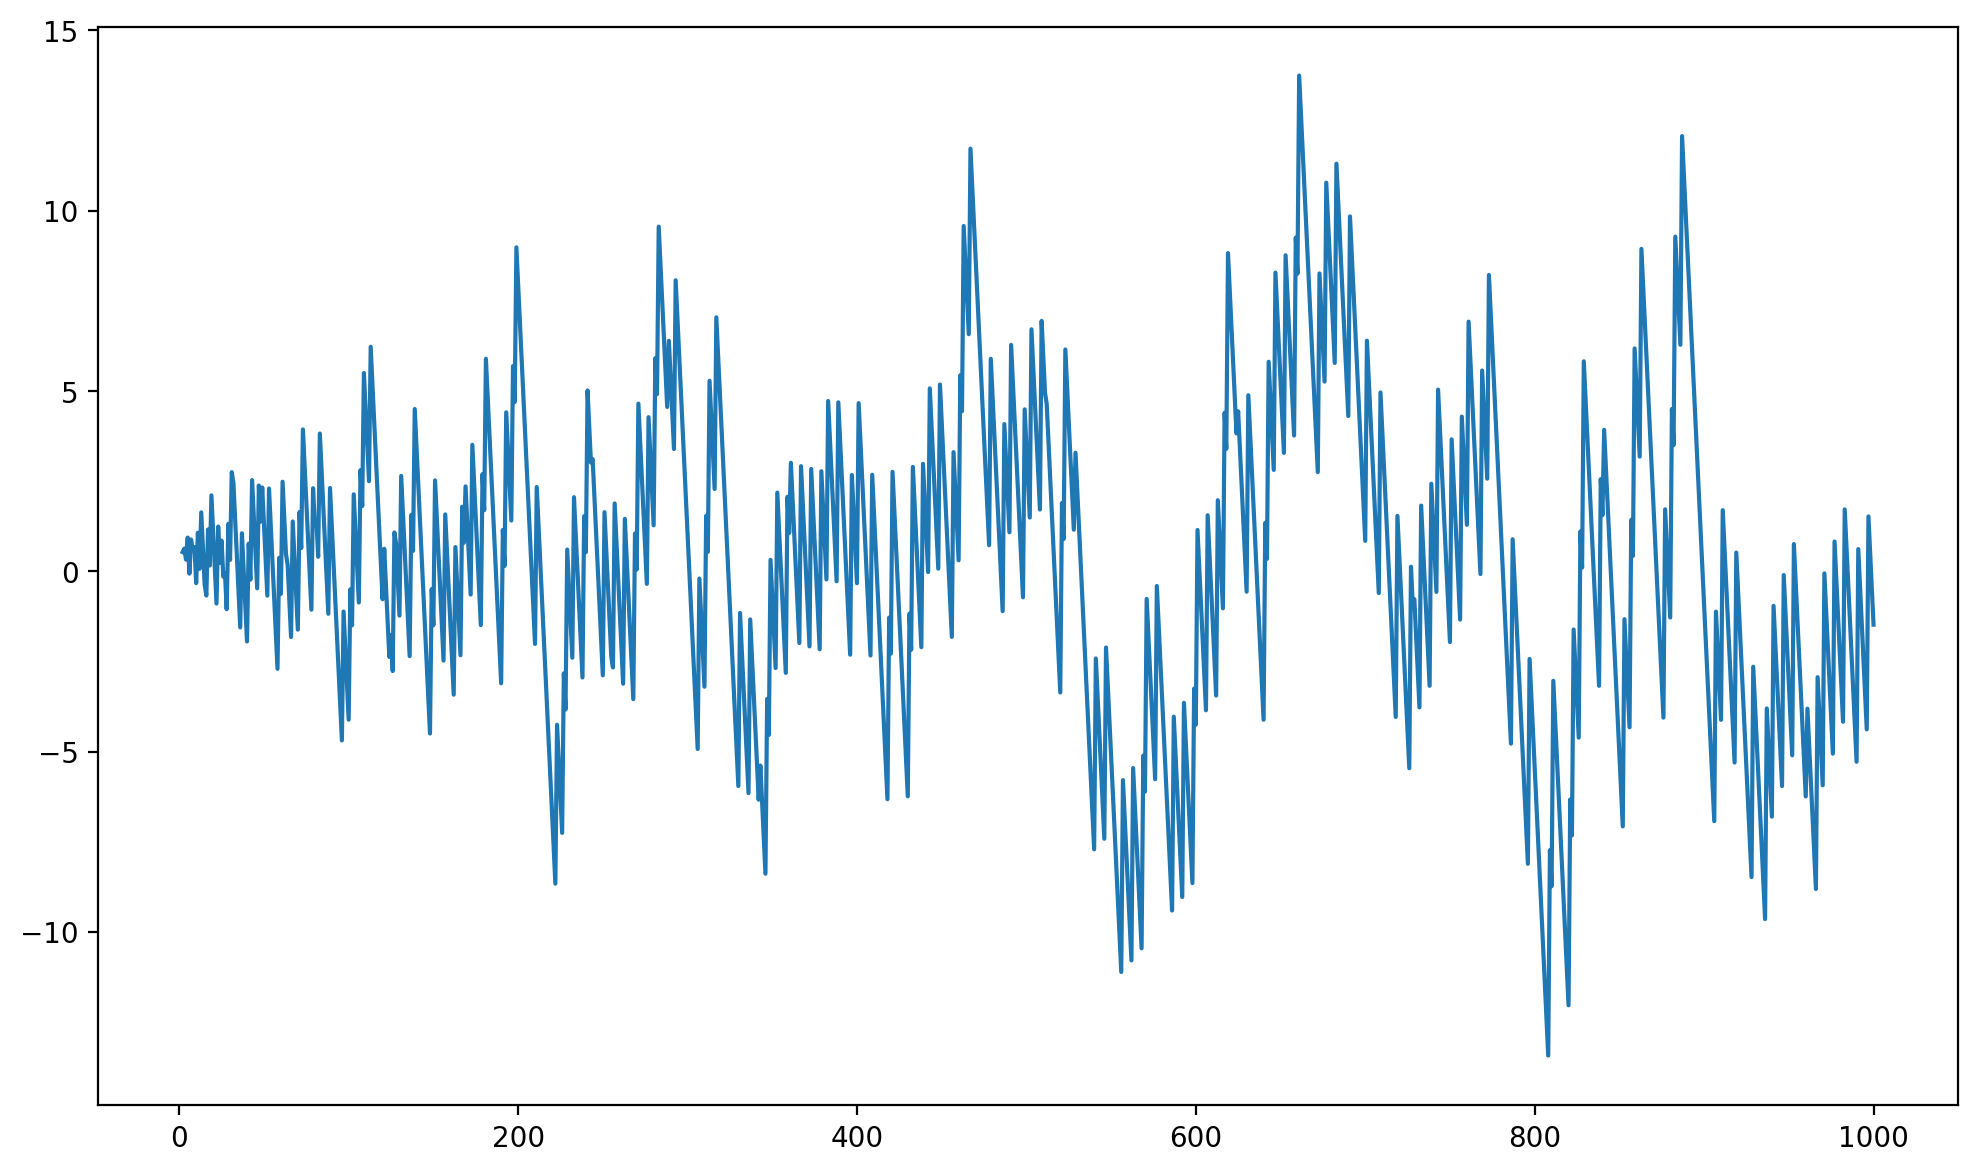

In [23]:
ys = [zeta_poly(x) for x in range(2,1001)]
xs = [x for x in range(2,1001)]
ys1 = [(cheb2(x)-x+math.log(2*math.pi)) for x in range(2,1001)]
#plt.plot(xs,ys)
plt.plot(xs,ys1)


The reason for this relationship is Riemann's [*explicit formula*](https://en.wikipedia.org/wiki/Explicit_formulae_for_L-functions) which shows that the difference between $\psi(x) - x + \log(2\pi)$ and the sum $\sum x^\rho/\rho$ over *all* non-trivial zeros $\rho$ tends to 0 as $x \to \infty$.

## Part 4: "music" of the primes

If $\rho = 1/2 + it$ then the term $x^\rho/\rho$ equals $x^{1/2}(\cos (t \log x) + i \sin (t \log x))/\rho$.  These cosine and sine terms are why people talk about the "music of the primes": cos and sin waves are how we represent pure musical tones.  You are now going to tranform the imaginary parts of the non-trivial zeros from `zeta_zero_imaginary_parts.txt` into sound.

To create a `.wav` sound file in Python we will produce a `numpy` array representing the sound wave and then pass it to a function called `scipy.io.wavfile.write`.  You also have to specify a "sample rate" - just use the value from my code below.  The next code cell creates a file with a pure sine wave tone, and the one after that will make it play in your browser.

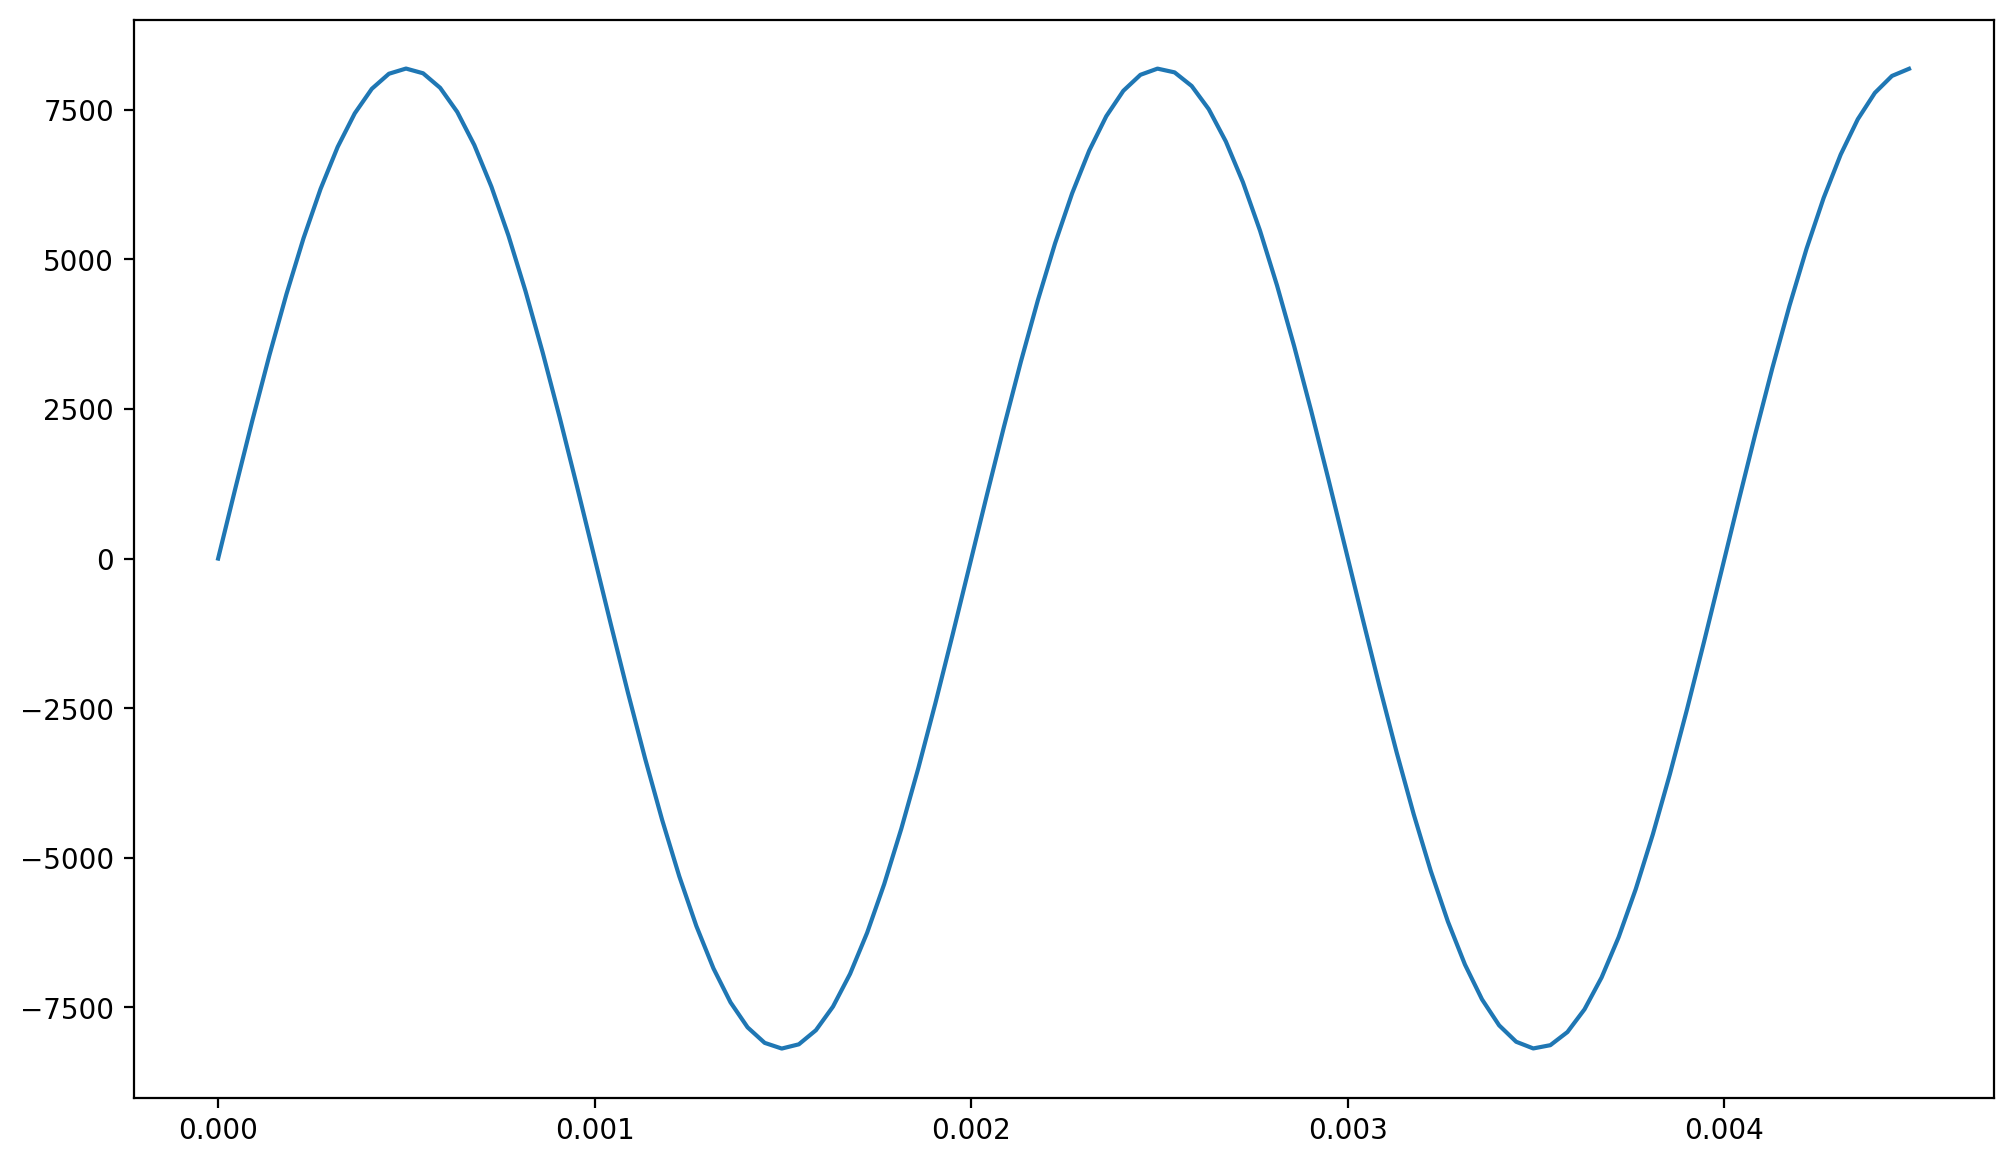

In [31]:
sample_rate = 22050 # samples per second
frequency = 500     # frequency in Hz of the tone we will generate
length = 1          # length of the sound in seconds
times = np.linspace(0, length, length * sample_rate) # sample times for 1 second of sound at 22050 samples per second
amplitude = 2 ** 13 # scale factor used to make the sound loud enough to hear
sound_data = amplitude * np.sin(2 * np.pi * frequency * times) # a 500Hz sine wave
plt.plot(times[:100], sound_data[:100])  # visualisation of part of the sound wave you are about to generate
scipy.io.wavfile.write("pure_tone.wav", sample_rate, sound_data.astype(np.int16)) # .astype converts the data
# to the correct kind of integer for use in a wav file.

In [32]:
IPython.display.Audio("pure_tone.wav") # load the sound for playing. You should see a player with a clickable > button.

You can make more complex tones by adding together sine waves. `numpy` arrays are great for this since + works the way you want.

Now **make a short sound file using the frequencies of the imaginary parts of the zeros from `zeta_zero_imaginary_parts.txt`.**  The following is a simple way to do this.
 - Choose a frequency scale factor $c$ (about 30 is OK).
 - For $0 \leqslant i \leqslant 19$, generate an array consisting of one second's worth of samples of the sum of $i$ sine waves with frequencies $ct_0, ct_1, \ldots, ct_i$, where $t_i$ is the imaginary part of the $i$th zeta zero, scaled by an amplitude $a_i$ (something like $a_i=2^{13}/(i+1)$ seems to work - **be careful** because if you mess this up the wav file can be LOUD or distorted).
 - Join these together into a single array, then write it out as a 20 second sound file. (`np.concatenate([a, b, c])` concatenates the 1-dimensional arrays `a`, `b`, and `c`)

You are free to be more creative if you want, so long as what you do uses only (a fixed multiple of) the frequencies from the zeros.  Following the instructions above will give an annoying click whenever a new frequency is added - you could think about how to remove this.

In [0]:
sample_rate = 22050 # samples per second
frequency = 30     # frequency in Hz of the tone we will generate
length = 20         # length of the sound in seconds
times = np.linspace(0, length, length * sample_rate) # sample times for 1 second of sound at 22050 samples per second
amplitude = 2 ** 13 # scale factor used to make the sound loud enough to hear
sound_data = amplitude * np.sin(2 * np.pi * frequency * times) # a 500Hz sine wave
plt.plot(times[:100], sound_data[:100])  # visualisation of part of the sound wave you are about to generate
scipy.io.wavfile.write("pure_tone.wav", sample_rate, sound_data.astype(np.int16)) # .astype converts the data
# to the correct kind of integer for use in a wav file.

In [0]:

zim = [14.134725142,21.022039639,25.010857580,30.424876126,32.935061588,37.586178159,40.918719012,43.327073281,48.005150881,49.773832478,52.970321478,56.446247697,59.347044003,60.831778525,65.112544048,67.079810529,69.546401711,72.067157674,75.704690699,77.144840069]
freq = 30
sample_rate = 22050
amplitude = 2**13
length = 1
times = np.linspace(0, length, length * sample_rate)



# Submitting your project

Check you have done the following.

0. Included **all** group members' student numbers at the top of this notebook.
1. Read through every exercise to check you have answered every part.
2. Carefully read and followed all of the [MATH0011 project instructions](https://www.ucl.ac.uk/~ucahmto/project_instructions.html).
3. Checked that all of the code in this notebook works correctly.

**One** group member should download the completed notebook (in CoCalc, click the File menu, then click Download File) and submit it on the MATH0011 Moodle page in the projects section.  Please submit **only one file per group.**